In [5]:
import numpy as np
import tensorflow as tf
import skimage
import pywt
import scipy

print(f"✅ NumPy: {np.__version__} (Compatible con TF)")
print(f"✅ Skimage: {skimage.__version__}")
print(f"✅ SciPy: {scipy.__version__}")
print(f"🚀 GPU: {tf.config.list_physical_devices('GPU')}")

2026-03-14 17:14:00.362134: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 17:14:00.386520: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-14 17:14:01.047846: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✅ NumPy: 1.23.5 (Compatible con TF)
✅ Skimage: 0.20.0
✅ SciPy: 1.10.1
🚀 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-14 17:14:02.171733: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 17:14:02.215196: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 17:14:02.215252: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [6]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Synthetic data generation

With the code above, a synthetic data was generated. There are 3 classes:
- Normal (pure sinusoidal)
- Sag
- Swell

It's the very first data generation. Gaussian noise was added to try to get more realistic signals.

In [7]:
import numpy as np
import pandas as pd

def generate_pq_data(n_samples=12000, fs=3200, T=10/60):
    """
    Generates a dataset of synthetic Power Quality signals.
    Classes: 0=Normal, 1=Sag, 2=Swell
    """
    t = np.linspace(0, T, int(T*fs)) # Time vector (10 cycles)
    data = []
    labels = []

    for _ in range(n_samples):
        # Base parameters
        freq = 60
        omega = 2 * np.pi * freq

        # Randomly choose a class
        event_type = np.random.choice(['Normal', 'Sag', 'Swell'])

        # Base Signal
        sig = np.sin(omega * t)

        # Apply Disturbance
        if event_type == 'Normal':
            label = 0
            # Just add random Gaussian noise
            noise = np.random.normal(0, 0.1, len(t))
            final_sig = sig + noise

        elif event_type == 'Sag':
            label = 1
            # Drop amplitude to 0.1 - 0.9 randomly
            mag = np.random.uniform(0.1, 0.9)
            start = np.random.randint(len(t)//4, len(t)//2)
            end = np.random.randint(start + 100, 3*len(t)//4)
            sig[start:end] *= mag
            noise = np.random.normal(0, 0.1, len(t))
            final_sig = sig + noise

        elif event_type == 'Swell':
            label = 2
            # Increase amplitude to 1.1 - 1.8 randomly
            mag = np.random.uniform(1.1, 1.8)
            start = np.random.randint(len(t)//4, len(t)//2)
            end = np.random.randint(start + 100, 3*len(t)//4)
            sig[start:end] *= mag
            noise = np.random.normal(0, 0.1, len(t))
            final_sig = sig + noise

        data.append(final_sig)
        labels.append(label)

    return np.array(data), np.array(labels)

# Generate and Save
X, y = generate_pq_data(n_samples=12000)
print(f"Generated Dataset: X shape={X.shape}, y shape={y.shape}")

#Save to CSV (optional)
pd.DataFrame(X).to_csv("12000_pq_dataset_X.csv", index=False)
pd.DataFrame(y).to_csv("12000_pq_dataset_y.csv", index=False)

Generated Dataset: X shape=(12000, 533), y shape=(12000,)


An example of the generated signals is presented in the next output from the block of code below:

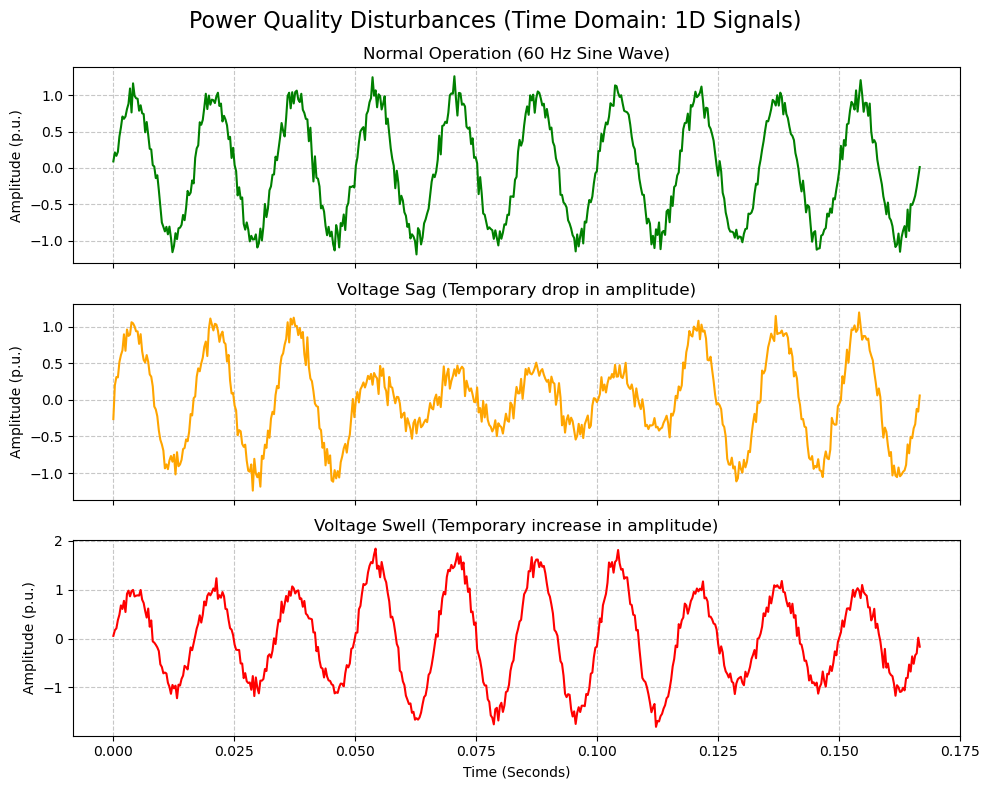

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_sample_signals(fs=3200, T=10/60):
    """Generates one Normal, one Sag, and one Swell signal for visualization."""
    t = np.linspace(0, T, int(T*fs)) # Time vector for 10 cycles (60Hz)
    omega = 2 * np.pi * 60

    # 1. Normal Signal (Just noise)
    sig_normal = np.sin(omega * t) + np.random.normal(0, 0.1, len(t))

    # 2. Voltage Sag (Drop to 40% amplitude in the middle)
    sig_sag = np.sin(omega * t)
    start_idx, end_idx = int(len(t)*0.3), int(len(t)*0.7)
    sig_sag[start_idx:end_idx] *= 0.4
    sig_sag += np.random.normal(0, 0.1, len(t))

    # 3. Voltage Swell (Spike to 160% amplitude in the middle)
    sig_swell = np.sin(omega * t)
    sig_swell[start_idx:end_idx] *= 1.6
    sig_swell += np.random.normal(0, 0.1, len(t))

    return t, sig_normal, sig_sag, sig_swell

# Generate the data
t, normal, sag, swell = generate_sample_signals()

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Power Quality Disturbances (Time Domain: 1D Signals)', fontsize=16)

# Plot Normal
axes[0].plot(t, normal, color='green')
axes[0].set_title('Normal Operation (60 Hz Sine Wave)')
axes[0].set_ylabel('Amplitude (p.u.)')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot Sag
axes[1].plot(t, sag, color='orange')
axes[1].set_title('Voltage Sag (Temporary drop in amplitude)')
axes[1].set_ylabel('Amplitude (p.u.)')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot Swell
axes[2].plot(t, swell, color='red')
axes[2].set_title('Voltage Swell (Temporary increase in amplitude)')
axes[2].set_xlabel('Time (Seconds)')
axes[2].set_ylabel('Amplitude (p.u.)')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Turning 1D series into 2D Spectograms


In [8]:
import os
import numpy as np
import pywt
import matplotlib.pyplot as plt

# 1. Signal Generation Function (from our previous step)
def generate_pq_data(n_samples=12000, fs=3200, T=10/60):
    """
    Generates synthetic 1D Power Quality signals.
    Generates an equal amount of Normal, Sag, and Swell signals.
    """
    t = np.linspace(0, T, int(T*fs), endpoint=False)
    data = []
    labels = []

    # Generate 4000 of each class to get 12000 total samples
    samples_per_class = n_samples // 3

    for class_label, event_type in enumerate(['Normal', 'Sag', 'Swell']):
        for _ in range(samples_per_class):
            omega = 2 * np.pi * 60
            sig = np.sin(omega * t)

            if event_type == 'Normal':
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            elif event_type == 'Sag':
                mag = np.random.uniform(0.1, 0.9)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            elif event_type == 'Swell':
                mag = np.random.uniform(1.1, 1.8)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            data.append(final_sig)
            labels.append(class_label)

    return np.array(data), np.array(labels)

# 2. CWT Transformation and Image Saving Function
def create_image_dataset(X, y, base_dir="pq_image_dataset"):
    """
    Applies CWT to 1D signals and saves them as 2D images in categorized folders.
    """
    classes = {0: "Normal", 1: "Sag", 2: "Swell"}

    # Create the directory structure (e.g., dataset/Normal/, dataset/Sag/)
    for cls_name in classes.values():
        os.makedirs(os.path.join(base_dir, cls_name), exist_ok=True)

    print(f"Saving images to: {os.path.abspath(base_dir)}")

    # Continuous Wavelet Transform Parameters
    scales = np.arange(1, 128)
    wavelet = 'cmor'  # Complex Morlet wavelet

    # Process each signal
    for i in range(len(X)):
        signal = X[i]
        label = y[i]
        class_name = classes[label]

        # Apply CWT
        # We only need the coefficients, not the frequencies
        coeffs, _ = pywt.cwt(signal, scales, wavelet)

        # Calculate the power (magnitude squared) to form the image pixels
        power = np.abs(coeffs)**2

        # Define the file path
        filename = os.path.join(base_dir, class_name, f"{class_name}_{i:04d}.png")

        # Save the 2D array directly as an image.
        # cmap='jet' gives it the classic thermal/spectrogram color mapping.
        # origin='lower' ensures the low frequencies (scale 1) are at the bottom.
        plt.imsave(filename, power, cmap='jet', origin='lower')

        # Print progress
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(X)} images...")

    print("Dataset generation successfully completed!")

# 3. Execution Block
if __name__ == "__main__":
    print("1. Generating 1D synthetic signals...")
    # Generating 12000 total signals (4000 per class) to keep the initial run fast.
    
    X_data, y_labels = generate_pq_data(n_samples=12000)

    print("2. Transforming to 2D Spectrograms and saving to disk...")
    create_image_dataset(X_data, y_labels, base_dir="12000_pq_spectrograms")

1. Generating 1D synthetic signals...
2. Transforming to 2D Spectrograms and saving to disk...
Saving images to: /mnt/c/py/ArtificialVision/12000_pq_spectrograms


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processed 100/12000 images...
Processed 200/12000 images...
Processed 300/12000 images...
Processed 400/12000 images...
Processed 500/12000 images...
Processed 600/12000 images...
Processed 700/12000 images...
Processed 800/12000 images...
Processed 900/12000 images...
Processed 1000/12000 images...
Processed 1100/12000 images...
Processed 1200/12000 images...
Processed 1300/12000 images...
Processed 1400/12000 images...
Processed 1500/12000 images...
Processed 1600/12000 images...
Processed 1700/12000 images...
Processed 1800/12000 images...
Processed 1900/12000 images...
Processed 2000/12000 images...
Processed 2100/12000 images...
Processed 2200/12000 images...
Processed 2300/12000 images...
Processed 2400/12000 images...
Processed 2500/12000 images...
Processed 2600/12000 images...
Processed 2700/12000 images...
Processed 2800/12000 images...
Processed 2900/12000 images...
Processed 3000/12000 images...
Processed 3100/12000 images...
Processed 3200/12000 images...
Processed 3300/12

In the next block of code we can visualize any signal and its corresponding spectogram. We just have to set a value for "sample_to_vie" variable


Visualizing sample index 5600...


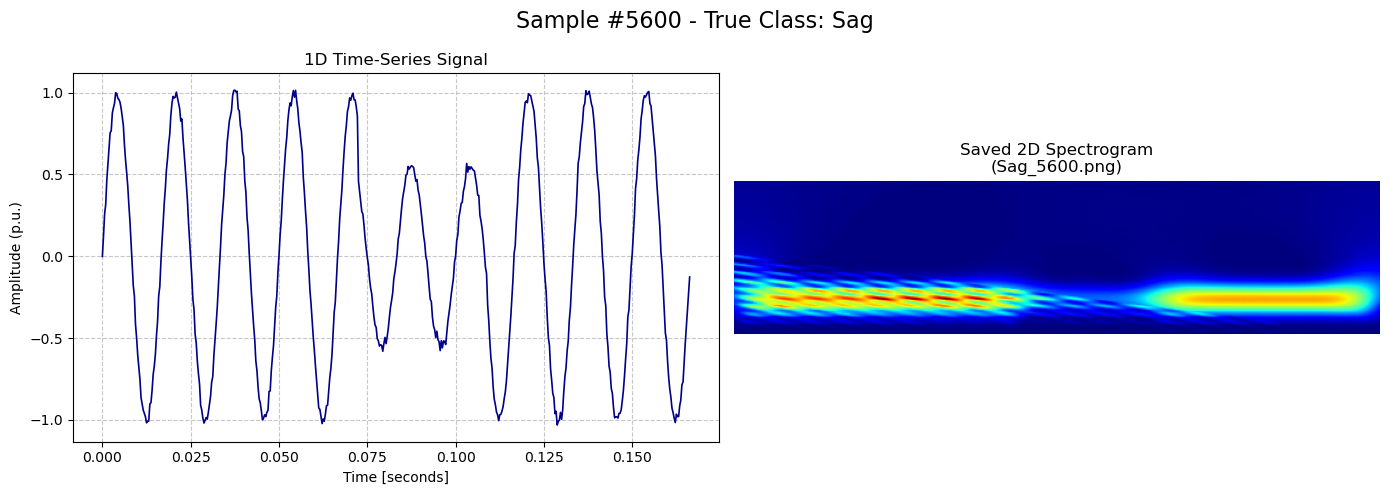

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def visualize_sample(X, y, sample_index, base_dir="12000_pq_spectrograms", fs=3200):
    """
    Plots a 1D signal from the dataset array and loads its corresponding
    saved 2D spectrogram image from the directory.
    """
    classes = {0: "Normal", 1: "Sag", 2: "Swell"}

    # 1. Get the 1D signal and its label
    signal = X[sample_index]
    label = y[sample_index]
    class_name = classes[label]

    # Create time vector for the 1D plot
    T = len(signal) / fs
    t = np.linspace(0, T, len(signal), endpoint=False)

    # 2. Construct the file path for the saved spectrogram
    # The filename was formatted as: ClassName_000X.png
    filename = f"{class_name}_{sample_index:04d}.png"
    filepath = os.path.join(base_dir, class_name, filename)

    # Check if the image exists
    if not os.path.exists(filepath):
        print(f"Error: Could not find image at {filepath}")
        return

    # Load the saved image
    spectrogram_img = mpimg.imread(filepath)

    # 3. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Sample #{sample_index} - True Class: {class_name}', fontsize=16)

    # Plot A: The 1D Signal
    axes[0].plot(t, signal, color='darkblue', linewidth=1.2)
    axes[0].set_title('1D Time-Series Signal')
    axes[0].set_xlabel('Time [seconds]')
    axes[0].set_ylabel('Amplitude (p.u.)')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot B: The Saved 2D Spectrogram
    # We hide the axes ticks since it's an image loaded from disk
    axes[1].imshow(spectrogram_img)
    axes[1].set_title(f'Saved 2D Spectrogram\n({filename})')
    axes[1].axis('off') # Hide axes for a clean image view

    plt.tight_layout()
    plt.show()

# --- Execution ---
# Choose which sample index you want to look at (e.g., sample 42)
# (Ensure X_data and y_labels exist from the previous generation script)
sample_to_view = 5600

print(f"Visualizing sample index {sample_to_view}...")
visualize_sample(X_data, y_labels, sample_index=sample_to_view)

Once we have generated a Histogram Dataset, we proceed to train a CNN just as follows:

Loading datasets...
Found 12000 files belonging to 3 classes.
Using 9600 files for training.


2026-03-14 17:39:24.571755: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 17:39:24.571887: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 17:39:24.571910: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 17:39:24.762134: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 17:39:24.762693: I tensorflow/compile

Found 12000 files belonging to 3 classes.
Using 2400 files for validation.
Target Classes: ['Normal', 'Sag', 'Swell']
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
    

2026-03-14 17:39:33.522242: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [9600]
	 [[{{node Placeholder/_0}}]]
2026-03-14 17:39:33.522482: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [9600]
	 [[{{node Placeholder/_0}}]]
2026-03-14 17:39:33.878969: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-14 17:39:37.676808: I tensorflow/compi

299/300 [============================>.] - ETA: 0s - loss: 0.0489 - accuracy: 0.9829

2026-03-14 17:39:49.559440: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2400]
	 [[{{node Placeholder/_4}}]]
2026-03-14 17:39:49.559688: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [2400]
	 [[{{node Placeholder/_0}}]]


300/300 [==============================] - 17s 31ms/step - loss: 0.0488 - accuracy: 0.9829 - val_loss: 8.1894e-06 - val_accuracy: 1.0000
Epoch 2/10
300/300 [==============================] - 9s 29ms/step - loss: 5.9424e-06 - accuracy: 1.0000 - val_loss: 1.6410e-06 - val_accuracy: 1.0000
Epoch 3/10
300/300 [==============================] - 10s 34ms/step - loss: 2.2481e-06 - accuracy: 1.0000 - val_loss: 5.7617e-07 - val_accuracy: 1.0000
Epoch 4/10
300/300 [==============================] - 9s 29ms/step - loss: 7.6258e-07 - accuracy: 1.0000 - val_loss: 3.2097e-07 - val_accuracy: 1.0000
Epoch 5/10
300/300 [==============================] - 9s 29ms/step - loss: 5.5985e-07 - accuracy: 1.0000 - val_loss: 1.9217e-07 - val_accuracy: 1.0000
Epoch 6/10
300/300 [==============================] - 9s 29ms/step - loss: 3.1406e-07 - accuracy: 1.0000 - val_loss: 1.1802e-07 - val_accuracy: 1.0000
Epoch 7/10
300/300 [==============================] - 10s 34ms/step - loss: 2.3889e-07 - accuracy: 1.0000 -

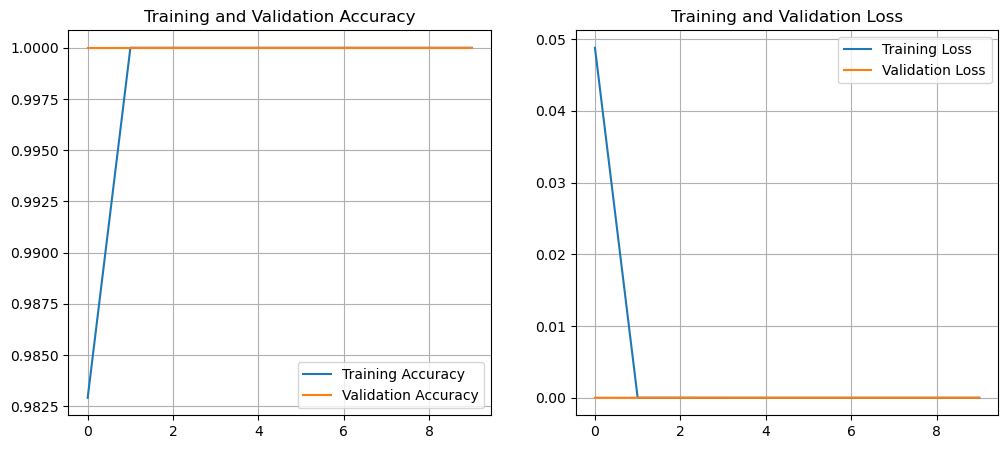

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Dataset Configuration
# We resize the spectrograms to 128x128 to balance detail and RAM efficiency.
batch_size = 32
img_height = 128
img_width = 128
data_dir = "12000_pq_spectrograms"  # The folder generated in Phase 2

print("Loading datasets...")
# Training dataset (80% of the data)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Validation dataset (20% of the data)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print(f"Target Classes: {class_names}")

# Optimize dataset loading for performance (crucial when scaling up to thousands of images)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Build the CNN Architecture
# This architecture is deep enough to catch transient visual features but
# light enough to avoid instant overfitting on our prototype dataset.
model = models.Sequential([
  # Preprocessing: Normalize pixel values from [0, 255] to [0, 1]
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  # Convolutional Block 1: Basic Edge/Line Detection
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Convolutional Block 2: Intermediate Patterns
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Convolutional Block 3: Complex Spectrogram Textures
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Regularization: Randomly drop 20% of neurons to force the network to
  # learn generalized features rather than memorizing the training noise
  layers.Dropout(0.2),

  # Classification Head
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(len(class_names)) # Output layer: 1 node per class
])

# 3. Compile the Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Print a summary of the network dimensions and parameters
model.summary()

# 4. Train the Network
epochs = 10
print(f"\nStarting training for {epochs} epochs...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

# 5. Visualize the Training Results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.show()

Extremely good results.

- No reliability on the results gotten due to the synthetic data is too perfect. 
- We must look for a dataset with real data.
- Just three classes are nothing for a CNN.

Next code add 6 different classes:
- Normal
- Sag
- Swell
- Harmonics
- Transient
- Complex

In [ ]:
import os
import numpy as np
import pywt
import matplotlib.pyplot as plt

def generate_complex_pq_data(n_samples_per_class=3000, fs=3200, T=10/60):
    """
    Generates a 6-class dataset of synthetic Power Quality signals.
    Classes: Normal, Sag, Swell, Harmonics, Transient, Complex
    """
    t = np.linspace(0, T, int(T*fs), endpoint=False)
    data = []
    labels = []

    classes = ['Normal', 'Sag', 'Swell', 'Harmonics', 'Transient', 'Complex']
    omega = 2 * np.pi * 60 # Fundamental frequency

    for class_label, event_type in enumerate(classes):
        for _ in range(n_samples_per_class):
            # Base 60Hz Signal
            sig = np.sin(omega * t)

            # 1. Normal
            if event_type == 'Normal':
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            # 2. Sag (10% to 90% drop)
            elif event_type == 'Sag':
                mag = np.random.uniform(0.1, 0.9)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            # 3. Swell (110% to 180% spike)
            elif event_type == 'Swell':
                mag = np.random.uniform(1.1, 1.8)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                sig[start:end] *= mag
                final_sig = sig + np.random.normal(0, 0.02, len(t))

            # 4. Harmonics (Adding 3rd, 5th, and 7th harmonics)
            elif event_type == 'Harmonics':
                alpha3 = np.random.uniform(0.05, 0.15)
                alpha5 = np.random.uniform(0.05, 0.10)
                alpha7 = np.random.uniform(0.01, 0.05)
                harmonic_sig = sig + (alpha3 * np.sin(3 * omega * t)) + \
                                     (alpha5 * np.sin(5 * omega * t)) + \
                                     (alpha7 * np.sin(7 * omega * t))
                final_sig = harmonic_sig + np.random.normal(0, 0.02, len(t))

            # 5. Oscillatory Transient (High frequency decaying ringing)
            elif event_type == 'Transient':
                transient_freq = np.random.uniform(500, 1500)
                tau = np.random.uniform(0.005, 0.015) # Decay rate
                start = np.random.randint(len(t)//4, 3*len(t)//4)

                # Create the decaying transient
                t_trans = t[start:] - t[start]
                transient = np.exp(-t_trans/tau) * np.sin(2 * np.pi * transient_freq * t_trans)

                final_sig = np.copy(sig)
                final_sig[start:] += transient * np.random.uniform(0.3, 0.8)
                final_sig += np.random.normal(0, 0.02, len(t))

            # 6. Complex (Sag + Harmonics)
            elif event_type == 'Complex':
                # First apply harmonics
                alpha3 = np.random.uniform(0.05, 0.15)
                alpha5 = np.random.uniform(0.05, 0.10)
                complex_sig = sig + (alpha3 * np.sin(3 * omega * t)) + (alpha5 * np.sin(5 * omega * t))

                # Then apply a Sag
                mag = np.random.uniform(0.2, 0.8)
                start = np.random.randint(len(t)//4, len(t)//2)
                end = np.random.randint(start + 100, 3*len(t)//4)
                complex_sig[start:end] *= mag

                final_sig = complex_sig + np.random.normal(0, 0.02, len(t))

            data.append(final_sig)
            labels.append(class_label)

    return np.array(data), np.array(labels)

def create_complex_image_dataset(X, y, base_dir="pq_complex_spectrograms"):
    classes = {0: "Normal", 1: "Sag", 2: "Swell", 3: "Harmonics", 4: "Transient", 5: "Complex"}

    for cls_name in classes.values():
        os.makedirs(os.path.join(base_dir, cls_name), exist_ok=True)

    print(f"Generating CWT Spectrograms in: {os.path.abspath(base_dir)}")
    scales = np.arange(1, 128)
    wavelet = 'cmor'

    for i in range(len(X)):
        signal = X[i]
        class_name = classes[y[i]]

        coeffs, _ = pywt.cwt(signal, scales, wavelet)
        power = np.abs(coeffs)**2

        filename = os.path.join(base_dir, class_name, f"{class_name}_{i:04d}.png")
        plt.imsave(filename, power, cmap='jet', origin='lower')

        if (i + 1) % 200 == 0:
            print(f"Processed {i + 1}/{len(X)} images...")

    print("Complex dataset generation successfully completed!")

# --- Execution ---
if __name__ == "__main__":
    print("1. Generating 1D complex synthetic signals (1200 total, 200 per class)...")
    X_data, y_labels = generate_complex_pq_data(n_samples_per_class=3000)

    print("2. Transforming to 2D Spectrograms and saving to disk...")
    # Saving to a new folder to avoid mixing with the old data
    create_complex_image_dataset(X_data, y_labels, base_dir="pq_complex_spectrograms")

1. Generating 1D complex synthetic signals (1200 total, 200 per class)...
2. Transforming to 2D Spectrograms and saving to disk...
Generating CWT Spectrograms in: d:\Users\190379\Desktop\tester\pq_complex_spectrograms


d:\Users\190379\AppData\Local\miniconda3\envs\vision\lib\site-packages\pywt\_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processed 200/18000 images...
Processed 400/18000 images...
Processed 600/18000 images...
Processed 800/18000 images...
Processed 1000/18000 images...
Processed 1200/18000 images...
Processed 1400/18000 images...
Processed 1600/18000 images...
Processed 1800/18000 images...
Processed 2000/18000 images...
Processed 2200/18000 images...
Processed 2400/18000 images...
Processed 2600/18000 images...
Processed 2800/18000 images...
Processed 3000/18000 images...
Processed 3200/18000 images...
Processed 3400/18000 images...
Processed 3600/18000 images...
Processed 3800/18000 images...
Processed 4000/18000 images...
Processed 4200/18000 images...
Processed 4400/18000 images...
Processed 4600/18000 images...
Processed 4800/18000 images...
Processed 5000/18000 images...
Processed 5200/18000 images...
Processed 5400/18000 images...
Processed 5600/18000 images...
Processed 5800/18000 images...
Processed 6000/18000 images...
Processed 6200/18000 images...
Processed 6400/18000 images...
Processed 66

The training for the new model that considers 6 classes

2026-03-12 11:48:26.514556: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 11:48:26.546508: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-12 11:48:27.153229: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading complex datasets...
Found 18000 files belonging to 6 classes.
Using 14400 files for training.


2026-03-12 11:48:36.217497: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-12 11:48:36.247607: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-12 11:48:36.247668: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-12 11:48:36.248826: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-12 11:48:36.248873: I tensorflow/compile

Found 18000 files belonging to 6 classes.
Using 3600 files for validation.
Target Classes: ['Complex', 'Harmonics', 'Normal', 'Sag', 'Swell', 'Transient']

Starting training for 12 epochs...
Epoch 1/12


2026-03-12 11:48:44.152471: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [14400]
	 [[{{node Placeholder/_4}}]]
2026-03-12 11:48:44.152772: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [14400]
	 [[{{node Placeholder/_0}}]]
2026-03-12 11:48:49.910058: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8907
2026-03-12 11:48:50.503627: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-03-12

450/450 [==============================] - ETA: 0s - loss: 0.7436 - accuracy: 0.6292

2026-03-12 11:49:01.726740: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3600]
	 [[{{node Placeholder/_4}}]]
2026-03-12 11:49:01.727107: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3600]
	 [[{{node Placeholder/_0}}]]


450/450 [==============================] - 19s 25ms/step - loss: 0.7436 - accuracy: 0.6292 - val_loss: 0.4741 - val_accuracy: 0.7675
Epoch 2/12
450/450 [==============================] - 10s 23ms/step - loss: 0.4072 - accuracy: 0.8133 - val_loss: 0.1439 - val_accuracy: 0.9442
Epoch 3/12
450/450 [==============================] - 11s 24ms/step - loss: 0.1698 - accuracy: 0.9204 - val_loss: 0.1425 - val_accuracy: 0.9314
Epoch 4/12
450/450 [==============================] - 11s 24ms/step - loss: 0.1584 - accuracy: 0.9267 - val_loss: 0.1390 - val_accuracy: 0.9461
Epoch 5/12
450/450 [==============================] - 11s 24ms/step - loss: 0.1582 - accuracy: 0.9228 - val_loss: 0.1231 - val_accuracy: 0.9450
Epoch 6/12
450/450 [==============================] - 10s 23ms/step - loss: 0.1595 - accuracy: 0.9231 - val_loss: 0.1495 - val_accuracy: 0.9289
Epoch 7/12
450/450 [==============================] - 10s 23ms/step - loss: 0.1548 - accuracy: 0.9264 - val_loss: 0.1388 - val_accuracy: 0.9350
Epo

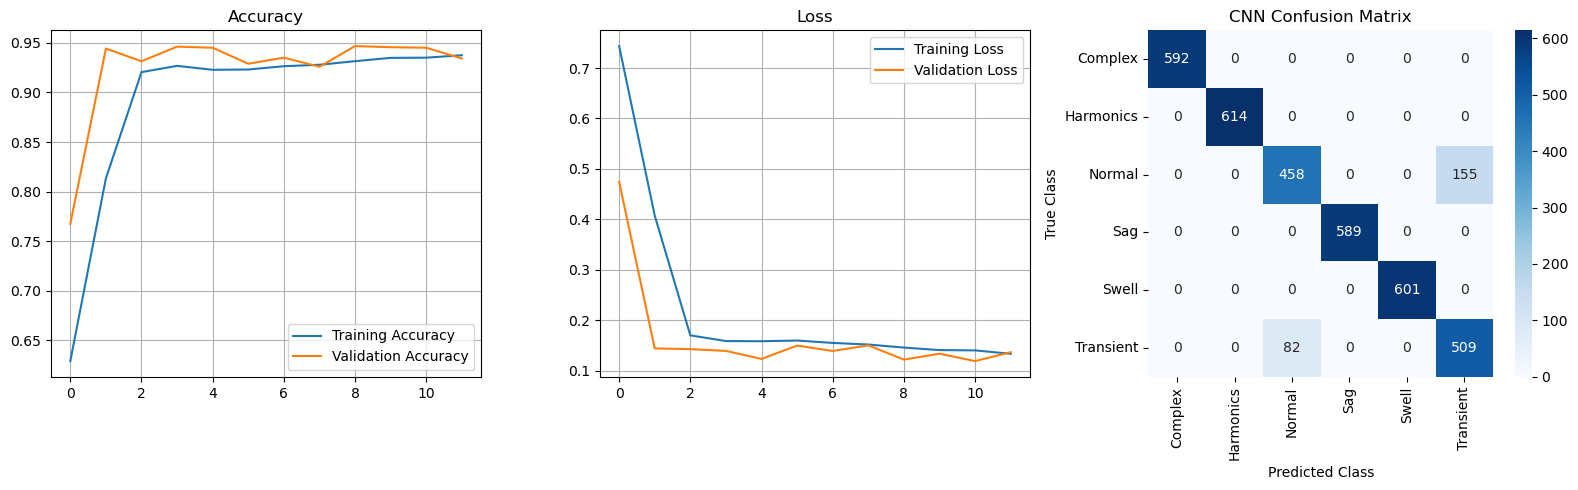


--- Proposed CNN Results ---
              precision    recall  f1-score   support

     Complex       1.00      1.00      1.00       592
   Harmonics       1.00      1.00      1.00       614
      Normal       0.85      0.75      0.79       613
         Sag       1.00      1.00      1.00       589
       Swell       1.00      1.00      1.00       601
   Transient       0.77      0.86      0.81       591

    accuracy                           0.93      3600
   macro avg       0.94      0.93      0.93      3600
weighted avg       0.94      0.93      0.93      3600



In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
#----------
# 1. Dataset Configuration
batch_size = 32
img_height = 128
img_width = 128
data_dir = "pq_complex_spectrograms"

print("Loading complex datasets...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size) # <-- shuffle=False has been removed!

class_names = train_ds.class_names
print(f"Target Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

#----------


# 2. Build the Advanced CNN Architecture
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

  # Block 1: Extracts basic horizontal/vertical lines (Grid frequency vs Transients)
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Block 2: Extracts texture patterns (Harmonic bands)
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Block 3: Extracts complex overlapping features (Sag + Harmonics)
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  # Flatten and Classify
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3), # Increased dropout to 30% to prevent overfitting on complex noise
  layers.Dense(len(class_names)) # 6 output nodes now
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Train the Network
epochs = 12
print(f"\nStarting training for {epochs} epochs...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

# 4. Generate Predictions for the Confusion Matrix
print("\nGenerating predictions for Validation Set...")
# Extract the true labels from the validation dataset
y_true = np.concatenate([y for x, y in val_ds], axis=0)

# Get the model's predictions (logits) and find the highest probability class
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

# 5. Visualizations
# Plot A: Accuracy & Loss Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss')
plt.grid(True)

# Plot B: Confusion Matrix
plt.subplot(1, 3, 3)
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')

plt.tight_layout()
plt.show()

# 6. Final Report
print("\n--- Proposed CNN Results ---")
print(classification_report(y_true, y_pred, target_names=class_names))

We obtain more reliable results.
- Even when we don't have a massive dataset.
- Adding gaussian noise is a good idea for realistic results.
- For 6 classes we can reach an accuracy of 93%